In [1]:
# Cell 1 – imports & global parameters

import os
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from Bio import SeqIO
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

import traceback
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

# pydeseq2
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm

print("pydeseq2 version:", getattr(pydeseq2, "__version__", "unknown"))

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from tqdm import tqdm    # you already use it in other cells


# === PATHS: adjust WORKDIR only ===
WORKDIR = Path("/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2")
OUTDIR = WORKDIR / "DESeq2_results"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Gene dictionary (relative to WORKDIR)
DICT_PATH = WORKDIR / "gene_dictionary.csv"

if not DICT_PATH.exists():
    raise FileNotFoundError(f"Gene mapping dictionary not found at: {DICT_PATH}")

# GenBank files for GO annotations
GBK_9A5C = WORKDIR.parent / "Arquivos brutos/genomes_9a5c_temecula1/9a5c.gbff"
GBK_TEM  = WORKDIR.parent / "Arquivos brutos/genomes_9a5c_temecula1/temecula1.gbff"

# Virulence gene table (your curated PD#### list with Function / Phase)
VIR_TABLE = Path(
    "/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/"
    "Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM/virulence_table.csv"
)

# Output file for the clustermap
VIR_HEATMAP = Path(
    "/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/"
    "Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM/virulence_clustermap.tiff"
)


print("WORKDIR:", WORKDIR.resolve())
print("OUTDIR:", OUTDIR.resolve())
print("DICT_PATH:", DICT_PATH.resolve())
print("VIR_TABLE:", VIR_TABLE.resolve())
print("VIR_HEATMAP:", VIR_HEATMAP.resolve())
print("GBK_9A5C exists:", GBK_9A5C.exists())
print("GBK_TEM exists:", GBK_TEM.exists())

# DESeq2 thresholds
ALPHA = 0.05
LFC_CUTOFF = 1.0  # |log2FC| > 1

pydeseq2 version: 0.5.2
WORKDIR: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2
OUTDIR: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results
DICT_PATH: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/gene_dictionary.csv
VIR_TABLE: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM/virulence_table.csv
VIR_HEATMAP: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM/virulence_clustermap.tiff
GBK_9A5C exists: True
GBK_TEM exists: True


In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [2]:
# Cell 2 – load gene dictionary & build ID mapping helpers

dict_df = pd.read_csv(DICT_PATH, sep="\t")
print(f"Loaded gene mapping dictionary with {len(dict_df)} entries")

# Mapping between IMG IDs
tem_to_9a = dict(zip(dict_df["Temecula1_IMG_ID"], dict_df["9a5c_IMG_ID"]))
a9_to_tem = dict(zip(dict_df["9a5c_IMG_ID"], dict_df["Temecula1_IMG_ID"]))

# Mapping IMG -> old locus tags (prefer tag without underscore)
def choose_old_tag(s: str | None) -> str | None:
    if s is None or pd.isna(s):
        return None
    parts = re.split(r"[\s,;|]+", str(s).strip())
    # prefer no underscore
    for p in parts:
        if p and "_" not in p:
            return p
    # fallback: first non-empty
    for p in parts:
        if p:
            return p
    return None

map_9a_img_to_old = {}
map_tem_img_to_old = {}

if "9a5c_IMG_ID" in dict_df.columns and "9a5c_old_locus_tags" in dict_df.columns:
    map_9a_img_to_old = {
        img: choose_old_tag(oldtags)
        for img, oldtags in zip(dict_df["9a5c_IMG_ID"], dict_df["9a5c_old_locus_tags"])
        if pd.notna(img)
    }

if "Temecula1_IMG_ID" in dict_df.columns and "Temecula1_old_locus_tags" in dict_df.columns:
    map_tem_img_to_old = {
        img: choose_old_tag(oldtags)
        for img, oldtags in zip(dict_df["Temecula1_IMG_ID"], dict_df["Temecula1_old_locus_tags"])
        if pd.notna(img)
    }

print("IMG→old locus tags mapping sizes:",
      "9a5c:", len(map_9a_img_to_old),
      "Temecula1:", len(map_tem_img_to_old))

Loaded gene mapping dictionary with 1831 entries
IMG→old locus tags mapping sizes: 9a5c: 1740 Temecula1: 1726


In [3]:
# Cell 3 – load all count .txt files and build counts_df + sample_df

files = sorted([f for f in os.listdir(WORKDIR) if f.lower().endswith(".txt")])
if not files:
    raise FileNotFoundError(f"No .txt count files found in {WORKDIR}")

count_dfs = []
meta_rows = []

pattern = re.compile(
    r'(?i)^(?P<strain>9a5c|9a|temecula1|tem|temp|temecula)'  # strain
    r'(?:_|-)?'
    r'(?P<medium>PIM6|PWG|pim6|pwg)'                        # medium
    r'(?:_|-)?(?P<timepoint>\d+)d'                          # timepoint
    r'(?:_|-)?(?P<replicate>\d+)?'                          # replicate (optional)
)

for fname in files:
    path = WORKDIR / fname

    # robust read: whitespace-delimited, keep first 2 cols
    try:
        df = pd.read_csv(path, delim_whitespace=True, header=None,
                         usecols=[0, 1], names=["gene_id", fname])
    except Exception:
        tmp = pd.read_csv(path, sep="\t", header=None, engine="python")
        tmp = tmp.iloc[:, :2]
        tmp.columns = ["gene_id", fname]
        df = tmp

    df = df.dropna(subset=["gene_id"]).set_index("gene_id")
    count_dfs.append(df)

    base = Path(fname).stem
    m = pattern.search(base)
    if m:
        g = m.groupdict()
        strain_raw = g.get("strain") or ""
        if strain_raw.lower().startswith("9a"):
            strain = "9a5c"
        else:
            strain = "Temecula1"
        medium = g.get("medium").upper()
        timepoint = int(g.get("timepoint"))
        replicate = int(g.get("replicate")) if g.get("replicate") else None
    else:
        # fallback parsing
        if "9a" in base.lower():
            strain = "9a5c"
        else:
            strain = "Temecula1"
        medium = "PIM6" if "pim6" in base.lower() else ("PWG" if "pwg" in base.lower() else "UNK")
        tp_match = re.search(r"(\d+)d", base, re.IGNORECASE)
        timepoint = int(tp_match.group(1)) if tp_match else None
        rep_match = re.search(r"_(\d+)$|(\d)$", base)
        replicate = int(rep_match.group(1) or rep_match.group(2)) if rep_match else None

    cond_label = f"{strain}_{medium}_{timepoint}d" if (strain and medium and timepoint is not None) else base

    meta_rows.append({
        "samplename": fname,
        "strain": strain,
        "medium": medium,
        "timepoint": timepoint,
        "replicate": replicate,
        "condition": cond_label
    })

# merge all
counts_df = pd.concat(count_dfs, axis=1, join="outer").fillna(0).astype(int)
counts_df = counts_df.loc[counts_df.sum(axis=1) > 0]  # drop all-zero genes

sample_df = pd.DataFrame(meta_rows).set_index("samplename")
sample_df = sample_df.reindex(counts_df.columns)

for col in ["condition", "strain", "medium", "replicate"]:
    sample_df[col] = sample_df[col].astype("category")

print("Loaded files:", len(files))
print("Counts matrix shape (genes x samples):", counts_df.shape)
print("Sample metadata shape:", sample_df.shape)
display(sample_df.head())

Loaded files: 24
Counts matrix shape (genes x samples): (4809, 24)
Sample metadata shape: (24, 5)


,strain,medium,timepoint,replicate,condition
9aPIM61d1.txt,9a5c,PIM6,1,1,9a5c_PIM6_1d
9aPIM61d2.txt,9a5c,PIM6,1,2,9a5c_PIM6_1d
9aPIM61d3.txt,9a5c,PIM6,1,3,9a5c_PIM6_1d
9aPIM63d1.txt,9a5c,PIM6,3,1,9a5c_PIM6_3d
9aPIM63d2.txt,9a5c,PIM6,3,2,9a5c_PIM6_3d


In [4]:
# Cell 4 – define comparisons by condition label

comparisons = [
    # Level A (time within strain+medium)
    ("9a5c_PIM6_1d", "9a5c_PIM6_3d"),
    ("9a5c_PWG_3d",  "9a5c_PWG_10d"),
    ("Temecula1_PIM6_1d", "Temecula1_PIM6_3d"),
    ("Temecula1_PWG_3d",  "Temecula1_PWG_7d"),

    # Level B (medium within strain)
    ("9a5c_PIM6_1d", "9a5c_PWG_3d"),
    ("9a5c_PIM6_3d", "9a5c_PWG_10d"),
    ("Temecula1_PIM6_1d", "Temecula1_PWG_3d"),
    ("Temecula1_PIM6_3d", "Temecula1_PWG_7d"),

    # Level C (strain within same medium/time)
    ("9a5c_PIM6_1d", "Temecula1_PIM6_1d"),
    ("9a5c_PIM6_3d", "Temecula1_PIM6_3d"),
    ("9a5c_PWG_3d",  "Temecula1_PWG_3d"),
    ("9a5c_PWG_10d", "Temecula1_PWG_7d"),
]

valid_comparisons = []
for c1, c2 in comparisons:
    n1 = (sample_df["condition"] == c1).sum()
    n2 = (sample_df["condition"] == c2).sum()
    if n1 > 0 and n2 > 0:
        print(f"{c1} vs {c2}: {n1} vs {n2} samples")
        valid_comparisons.append((c1, c2))
    else:
        print(f"SKIPPING {c1} vs {c2}: missing samples")

print("\nWill run comparisons:", len(valid_comparisons))
for a, b in valid_comparisons:
    print(" -", a, "vs", b)

9a5c_PIM6_1d vs 9a5c_PIM6_3d: 3 vs 3 samples
9a5c_PWG_3d vs 9a5c_PWG_10d: 3 vs 3 samples
Temecula1_PIM6_1d vs Temecula1_PIM6_3d: 3 vs 3 samples
Temecula1_PWG_3d vs Temecula1_PWG_7d: 3 vs 3 samples
9a5c_PIM6_1d vs 9a5c_PWG_3d: 3 vs 3 samples
9a5c_PIM6_3d vs 9a5c_PWG_10d: 3 vs 3 samples
Temecula1_PIM6_1d vs Temecula1_PWG_3d: 3 vs 3 samples
Temecula1_PIM6_3d vs Temecula1_PWG_7d: 3 vs 3 samples
9a5c_PIM6_1d vs Temecula1_PIM6_1d: 3 vs 3 samples
9a5c_PIM6_3d vs Temecula1_PIM6_3d: 3 vs 3 samples
9a5c_PWG_3d vs Temecula1_PWG_3d: 3 vs 3 samples
9a5c_PWG_10d vs Temecula1_PWG_7d: 3 vs 3 samples

Will run comparisons: 12
 - 9a5c_PIM6_1d vs 9a5c_PIM6_3d
 - 9a5c_PWG_3d vs 9a5c_PWG_10d
 - Temecula1_PIM6_1d vs Temecula1_PIM6_3d
 - Temecula1_PWG_3d vs Temecula1_PWG_7d
 - 9a5c_PIM6_1d vs 9a5c_PWG_3d
 - 9a5c_PIM6_3d vs 9a5c_PWG_10d
 - Temecula1_PIM6_1d vs Temecula1_PWG_3d
 - Temecula1_PIM6_3d vs Temecula1_PWG_7d
 - 9a5c_PIM6_1d vs Temecula1_PIM6_1d
 - 9a5c_PIM6_3d vs Temecula1_PIM6_3d
 - 9a5c_PWG_3d vs T

In [5]:
# Cell 5 – GO parsing & enrichment helpers

def parse_gbk_for_go_terms(gbk_file: Path):
    """
    Parse a GenBank file and extract:
      - locus_to_go:  old_locus_tag -> [GO IDs]
      - go_term_to_description: GO ID -> description
    """
    locus_to_go = defaultdict(list)
    go_term_to_desc = {}

    if not gbk_file.exists():
        print(f"WARNING: GBK file not found: {gbk_file}")
        return {}, {}

    for record in SeqIO.parse(str(gbk_file), "genbank"):
        for feat in record.features:
            if feat.type != "CDS":
                continue

            # choose an old_locus_tag
            old_locus = None
            if "old_locus_tag" in feat.qualifiers:
                for tag in feat.qualifiers["old_locus_tag"]:
                    if "_" not in tag:
                        old_locus = tag
                        break
                if not old_locus and feat.qualifiers["old_locus_tag"]:
                    old_locus = feat.qualifiers["old_locus_tag"][0]

            go_terms = []
            for qualifier in ["GO_function", "GO_process", "GO_component"]:
                if qualifier in feat.qualifiers:
                    for go_annotation in feat.qualifiers[qualifier]:
                        if " - " in go_annotation:
                            go_id, desc = go_annotation.split(" - ", 1)
                            go_id = go_id.strip()
                            desc = desc.strip()
                        else:
                            go_id = go_annotation.strip()
                            desc = "No description available"

                        if go_id.startswith("GO:"):
                            go_terms.append(go_id)
                            if go_id not in go_term_to_desc:
                                go_term_to_desc[go_id] = desc

            if old_locus and go_terms:
                locus_to_go[old_locus].extend(go_terms)

    # ensure unique GO lists
    locus_to_go = {k: sorted(set(v)) for k, v in locus_to_go.items()}
    return locus_to_go, go_term_to_desc


def run_go_enrichment(deg_genes, background_go_dict, go_descriptions_dict):
    """
    Fisher's exact test GO enrichment for a DEG list against a background GO mapping.

    deg_genes: list of old_locus_tag (or keys of background_go_dict) that are DEGs.
    background_go_dict: {locus_tag: [GO IDs]}
    go_descriptions_dict: {GO ID: description}
    """
    results = []
    valid_deg_genes = [g for g in deg_genes if g in background_go_dict]

    if not valid_deg_genes:
        return pd.DataFrame()

    all_go_terms = set()
    for terms in background_go_dict.values():
        all_go_terms.update(terms)

    total_deg = len(valid_deg_genes)
    total_bg = len(background_go_dict)

    for go_term in all_go_terms:
        deg_with = sum(1 for gene in valid_deg_genes if go_term in background_go_dict[gene])
        bg_with = sum(1 for terms in background_go_dict.values() if go_term in terms)
        if deg_with == 0:
            continue

        deg_without = total_deg - deg_with
        bg_without = total_bg - bg_with

        table = [[deg_with, deg_without],
                 [bg_with, bg_without]]

        try:
            odds_ratio, p_value = fisher_exact(table, alternative="greater")
        except Exception:
            odds_ratio, p_value = 1.0, 1.0

        deg_pct = (deg_with / total_deg * 100) if total_deg else 0.0
        bg_pct = (bg_with / total_bg * 100) if total_bg else 0.0
        fold_enrich = deg_pct / bg_pct if bg_pct > 0 else np.inf

        results.append({
            "go_term": go_term,
            "go_description": go_descriptions_dict.get(go_term, "No description available"),
            "deg_count": deg_with,
            "bg_count": bg_with,
            "deg_total": total_deg,
            "bg_total": total_bg,
            "deg_percentage": deg_pct,
            "bg_percentage": bg_pct,
            "fold_enrichment": fold_enrich,
            "odds_ratio": odds_ratio,
            "p_value": p_value,
        })

    if not results:
        return pd.DataFrame()

    df = pd.DataFrame(results)
    df["p_adj"] = multipletests(df["p_value"], method="fdr_bh")[1]
    df = df.sort_values("p_adj")
    return df


def add_go_enrichment_to_comparison(comp_out: Path, c1: str, c2: str,
                                    background_go_dict: dict,
                                    go_descriptions_dict: dict):
    """
    For a given comparison folder, run GO enrichment on
    up_in_{c1}_old_locus_tags.txt and up_in_{c2}_old_locus_tags.txt,
    saving GO_enrichment_*.csv files.
    """
    try:
        old_locus_files = [
            (c1, comp_out / f"up_in_{c1}_old_locus_tags.txt"),
            (c2, comp_out / f"up_in_{c2}_old_locus_tags.txt"),
        ]

        any_success = False

        for cond_label, file_path in old_locus_files:
            if not file_path.exists():
                continue

            with open(file_path, "r") as f:
                deg_genes = [line.strip() for line in f if line.strip()]

            if not deg_genes:
                continue

            enr_df = run_go_enrichment(deg_genes, background_go_dict, go_descriptions_dict)
            if enr_df.empty:
                continue

            out_name = f"GO_enrichment_up_in_{cond_label}_old_locus_tags.csv"
            enr_df.to_csv(comp_out / out_name, index=False)
            any_success = True

        return any_success

    except Exception as e:
        tqdm.write(f"GO enrichment failed in {comp_out.name}: {e}")
        return False

In [6]:
# Cell 6 – build GO backgrounds (per strain and combined for cross-strain)

go_9a5c, go_9a5c_desc = parse_gbk_for_go_terms(GBK_9A5C)
go_tem,  go_tem_desc  = parse_gbk_for_go_terms(GBK_TEM)

tqdm.write(f"Loaded GO annotations: 9a5c={len(go_9a5c)} genes, Temecula1={len(go_tem)} genes")

def build_enrichment_background(c1, c2):
    """
    Choose GO background for a comparison:
      - within 9a5c: use 9a5c GO mapping
      - within Temecula1: use Temecula1 GO mapping
      - cross-strain: build combined background using ortholog pairs keyed by 9a5c old_locus_tag,
                      with union of GO terms, and merged descriptions.
    Returns (background_go_dict, go_descriptions_dict)
    """
    is_9a_only = c1.startswith("9a5c") and c2.startswith("9a5c")
    is_tem_only = c1.startswith("Temecula1") and c2.startswith("Temecula1")
    is_cross = (c1.startswith("9a5c") and c2.startswith("Temecula1")) or \
               (c1.startswith("Temecula1") and c2.startswith("9a5c"))

    if is_9a_only:
        return go_9a5c, go_9a5c_desc

    if is_tem_only:
        return go_tem, go_tem_desc

    if is_cross:
        combined_bg = {}
        combined_desc = {}

        if not {"Temecula1_IMG_ID", "9a5c_IMG_ID"}.issubset(dict_df.columns):
            tqdm.write("Warning: dict_df missing IMG-ID orthology columns; falling back to union background.")
        else:
            for _, row in dict_df.iterrows():
                a9_img = row.get("9a5c_IMG_ID")
                tem_img = row.get("Temecula1_IMG_ID")
                if pd.isna(a9_img) or pd.isna(tem_img):
                    continue

                a9_old = map_9a_img_to_old.get(a9_img)
                tem_old = map_tem_img_to_old.get(tem_img)
                if not a9_old and not tem_old:
                    continue

                terms = set()
                if a9_old in go_9a5c:
                    terms.update(go_9a5c[a9_old])
                if tem_old in go_tem:
                    terms.update(go_tem[tem_old])
                if not terms:
                    continue

                combined_bg[a9_old] = sorted(terms)

            # build combined descriptions
            combined_desc.update(go_9a5c_desc)
            combined_desc.update(go_tem_desc)

        if not combined_bg:
            tqdm.write("Warning: combined background empty; using union of both strain backgrounds.")
            union_bg = {}
            for k, v in list(go_9a5c.items()) + list(go_tem.items()):
                union_bg.setdefault(k, set()).update(v)
            union_bg = {k: sorted(v) for k, v in union_bg.items()}
            union_desc = {}
            union_desc.update(go_9a5c_desc)
            union_desc.update(go_tem_desc)
            return union_bg, union_desc

        return combined_bg, combined_desc

    # fallback: union
    union_bg = {}
    for k, v in list(go_9a5c.items()) + list(go_tem.items()):
        union_bg.setdefault(k, set()).update(v)
    union_bg = {k: sorted(v) for k, v in union_bg.items()}
    union_desc = {}
    union_desc.update(go_9a5c_desc)
    union_desc.update(go_tem_desc)
    return union_bg, union_desc

Loaded GO annotations: 9a5c=1318 genes, Temecula1=1244 genes


In [7]:
# Cell 7 – safe mapping of gene IDs between strains (Temecula1 IMG -> 9a5c IMG)

def safe_map_gene_ids(counts_df_local: pd.DataFrame, mapper: dict) -> pd.DataFrame:
    """
    Map gene IDs in counts_df_local (index = gene IDs) using mapper (old -> new).
    Returns a new counts df indexed by mapped gene_id, summing if many->one.
    """
    mapped = counts_df_local.reset_index()
    gene_col = mapped.columns[0]
    mapped = mapped.rename(columns={gene_col: "original_gene_id"})
    mapped["gene_id"] = mapped["original_gene_id"].map(mapper)
    mapped = mapped.dropna(subset=["gene_id"]).drop(columns=["original_gene_id"])
    mapped = mapped.set_index("gene_id").groupby("gene_id").sum()
    return mapped

In [9]:
# Cell 8 – main DESeq2 + GO loop over all comparisons, with GO enrichment

summary_rows = []

for c1, c2 in tqdm(valid_comparisons, desc="comparisons", unit="comp"):
    comp_name = f"{c1}_vs_{c2}".replace("/", "_")
    comp_out = OUTDIR / comp_name
    comp_out.mkdir(parents=True, exist_ok=True)

    n_genes_tested = 0
    n_DEGs = 0
    up_in_c1 = 0
    up_in_c2 = 0
    error_msg = None

    try:
        # subset metadata & counts
        mask = sample_df["condition"].isin([c1, c2])
        sub_samples = sample_df.loc[mask].copy()
        if sub_samples.shape[0] == 0:
            raise RuntimeError(f"No samples found for {c1} or {c2}")

        sub_counts = counts_df.loc[:, sub_samples.index]
        sub_counts = sub_counts.loc[sub_counts.sum(axis=1) > 0, :]
        n_genes_tested = int(sub_counts.shape[0])
        if n_genes_tested == 0:
            raise RuntimeError("No genes left after filtering zero-sum across selected samples")

        # cross-strain?
        is_strain_comparison = ("9a5c" in c1 and "Temecula1" in c2) or \
                               ("Temecula1" in c1 and "9a5c" in c2)
        if is_strain_comparison:
            if "Temecula1_IMG_ID" not in dict_df.columns or "9a5c_IMG_ID" not in dict_df.columns:
                raise RuntimeError("dict_df missing 'Temecula1_IMG_ID' or '9a5c_IMG_ID'")

            tem_samples = sub_samples[sub_samples["strain"] == "Temecula1"].index.tolist()
            a9_samples  = sub_samples[sub_samples["strain"] == "9a5c"].index.tolist()

            counts_tem = sub_counts.loc[:, tem_samples] if tem_samples else pd.DataFrame(index=sub_counts.index)
            counts_a9  = sub_counts.loc[:, a9_samples] if a9_samples else pd.DataFrame(index=sub_counts.index)

            # Map Temecula IMG -> 9a IMG
            counts_tem_mapped = safe_map_gene_ids(counts_tem, tem_to_9a)
            # align
            common = counts_a9.index.intersection(counts_tem_mapped.index)
            if len(common) == 0:
                raise RuntimeError("No common genes after mapping between strains")

            sub_counts = pd.concat([counts_a9.loc[common], counts_tem_mapped.loc[common]], axis=1)
            sub_samples = sub_samples.loc[sub_counts.columns]

            # re-filter
            sub_counts = sub_counts.loc[sub_counts.sum(axis=1) > 0, :]
            n_genes_tested = int(sub_counts.shape[0])
            if n_genes_tested == 0:
                raise RuntimeError("No genes remain after mapping + filtering")

        # ensure ≥2 replicates per condition
        group_counts = sub_samples["condition"].value_counts().to_dict()
        if group_counts.get(c1, 0) < 2 or group_counts.get(c2, 0) < 2:
            raise RuntimeError(f"Not enough replicates per group: {group_counts}")

        # define DESeq2 group factor
        sub_samples = sub_samples.copy()
        sub_samples["group"] = np.where(sub_samples["condition"] == c1, "group1", "group2")
        sub_samples["group"] = pd.Categorical(sub_samples["group"],
                                              categories=["group2", "group1"])

        tqdm.write(f"Running DESeq2 for {comp_name} (samples={sub_counts.shape[1]}, genes={n_genes_tested})")

        dds = DeseqDataSet(
            counts=sub_counts.T,   # samples x genes
            metadata=sub_samples,
            design="group",
            refit_cooks=True,
        )
        dds.deseq2()

        stat = DeseqStats(
            dds,
            contrast=["group", "group1", "group2"],  # c1 vs c2
            alpha=ALPHA,
            lfc_null=LFC_CUTOFF,
            alt_hypothesis="greaterAbs",
            cooks_filter=True,
            independent_filter=True,
        )
        stat.summary()

        res_df = stat.results_df.copy()
        # align with gene IDs
        if len(res_df) != sub_counts.shape[0]:
            raise RuntimeError("Mismatch between result rows and gene IDs.")
        res_df.index = sub_counts.index
        res_df.insert(0, "gene_id", res_df.index)

        res_df.to_csv(comp_out / "DESeq2_results_full.csv", index=False)

        # DEG filtering
        deg_mask = (
            res_df["padj"].notna() &
            (res_df["padj"] <= ALPHA) &
            (res_df["log2FoldChange"].abs() > LFC_CUTOFF)
        )
        degs = res_df.loc[deg_mask].copy()
        degs.to_csv(comp_out / f"DEGs_padj{ALPHA}_LFC{LFC_CUTOFF}.csv", index=False)

        n_DEGs = int(len(degs))
        up_in_c1 = int((degs["log2FoldChange"] >  LFC_CUTOFF).sum())
        up_in_c2 = int((degs["log2FoldChange"] < -LFC_CUTOFF).sum())

        # up lists (IMG IDs)
        degs.loc[degs["log2FoldChange"] >  LFC_CUTOFF, "gene_id"].to_csv(
            comp_out / f"up_in_{c1}.txt", index=False, header=False
        )
        degs.loc[degs["log2FoldChange"] < -LFC_CUTOFF, "gene_id"].to_csv(
            comp_out / f"up_in_{c2}.txt", index=False, header=False
        )

        # annotate DEGs with old locus tags
        annot = degs.copy()

        def map_to_old(gid):
            if gid in map_9a_img_to_old and map_9a_img_to_old[gid]:
                return map_9a_img_to_old[gid]
            if gid in map_tem_img_to_old and map_tem_img_to_old[gid]:
                return map_tem_img_to_old[gid]
            return ""

        annot["old_locus_tag"] = annot["gene_id"].map(map_to_old).fillna("")
        annot.to_csv(comp_out / f"DEGs_annotated_p{ALPHA}_LFC{LFC_CUTOFF}.csv", index=False)

        # up lists with old locus tag (fallback to IMG id)
        up1_old = annot.loc[annot["log2FoldChange"] >  LFC_CUTOFF, "old_locus_tag"]
        up1_old = up1_old.where(up1_old != "", annot.loc[annot["log2FoldChange"] >  LFC_CUTOFF, "gene_id"])
        up1_old.to_csv(comp_out / f"up_in_{c1}_locustag.txt", index=False, header=False)

        up2_old = annot.loc[annot["log2FoldChange"] < -LFC_CUTOFF, "old_locus_tag"]
        up2_old = up2_old.where(up2_old != "", annot.loc[annot["log2FoldChange"] < -LFC_CUTOFF, "gene_id"])
        up2_old.to_csv(comp_out / f"up_in_{c2}_locustag.txt", index=False, header=False)

        # up lists with old locus *only* (for GO)
        up1_old_only = annot.loc[annot["log2FoldChange"] >  LFC_CUTOFF, "old_locus_tag"]
        up1_old_only = up1_old_only[up1_old_only != ""]
        up1_old_only.to_csv(comp_out / f"up_in_{c1}_old_locus_tags.txt", index=False, header=False)

        up2_old_only = annot.loc[annot["log2FoldChange"] < -LFC_CUTOFF, "old_locus_tag"]
        up2_old_only = up2_old_only[up2_old_only != ""]
        up2_old_only.to_csv(comp_out / f"up_in_{c2}_old_locus_tags.txt", index=False, header=False)

        # normalized counts and size factors
        try:
            norm_counts, size_factors = deseq2_norm(sub_counts.T)
            norm_df = pd.DataFrame(norm_counts, index=sub_counts.columns, columns=sub_counts.index)
            sizef_df = pd.DataFrame(size_factors, index=sub_counts.columns, columns=["size_factor"])
            norm_df.to_csv(comp_out / "deseq2_normalized_counts.csv")
            sizef_df.to_csv(comp_out / "size_factors.csv")
        except Exception:
            (comp_out / "warning_normalization.txt").write_text("deseq2_norm failed:\n" + traceback.format_exc())

        # VST
        try:
            dds.vst(use_design=False, fit_type=None)
            vst_arr = dds.layers["vst_counts"]
            vst_df = pd.DataFrame(vst_arr, index=sub_counts.columns, columns=sub_counts.index)
            vst_df.to_csv(comp_out / "vst_counts.csv")
        except Exception:
            (comp_out / "warning_vst.txt").write_text("vst failed:\n" + traceback.format_exc())

        # GO enrichment
        if n_DEGs > 0:
            bg_go, bg_desc = build_enrichment_background(c1, c2)
            go_ok = add_go_enrichment_to_comparison(comp_out, c1, c2, bg_go, bg_desc)
            if go_ok:
                tqdm.write(f"  GO enrichment completed for {comp_name}")
            else:
                tqdm.write(f"  GO enrichment: no DEGs with GO annotations for {comp_name}")
        else:
            tqdm.write(f"  GO enrichment skipped for {comp_name} (no DEGs)")

        tqdm.write(f"Done {comp_name}: {n_DEGs} DEGs (up {up_in_c1} / {up_in_c2})")

    except Exception as e:
        error_msg = str(e)
        (comp_out / "error.txt").write_text(traceback.format_exc())
        tqdm.write(f"ERROR in {comp_name}: {error_msg}")

    summary_rows.append({
        "comparison": comp_name,
        "condition1": c1,
        "condition2": c2,
        "n_genes": n_genes_tested,
        "n_DEGs": n_DEGs,
        "up_in_c1": up_in_c1,
        "up_in_c2": up_in_c2,
        "error": error_msg,
    })

raw_summary_df = pd.DataFrame(summary_rows)
raw_summary_path = OUTDIR / "comparisons_summary_raw.csv"
raw_summary_df.to_csv(raw_summary_path, index=False)
tqdm.write("Raw summary written to: " + str(raw_summary_path))
display(raw_summary_df.head())

Fitting size factors...                                                                        | 0/12 [00:00<?, ?comp/s]
... done in 0.00 seconds.



Running DESeq2 for 9a5c_PIM6_1d_vs_9a5c_PIM6_3d (samples=6, genes=2477)
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.13 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.26 seconds.

Fitting LFCs...
... done in 0.10 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: group group1 vs group2
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                 
XF9a_00001   935.266389        0.368242  0.154845  0.000000  1.000000   
XF9a_00002   738.922374        1.084371  0.219006  0.385245  0.700056   
XF9a_00003   477.525753        0.681579  0.218419  0.000000  1.000000   
XF9a_00004    67.281905       -0.176575  0.253654  0.000000  1.000000   
XF9a_00005  3190.844863        1.165664  0.143912  1.151153  0.249669   
...                 ...             ...       ...       ...       ...   
XF9a_02639  1658.297176        0.770137  0.142857  0.000000  1.000000   
XF9a_02640     0.173121        1.636584  4.432888  0.143605  0.885813   
XF9a_02641  1265.077442        1.479923  0.130848  3.667792  0.000245   
XF9a_02642   569.699106        1.541298  0.200815  2.695504  0.007028   
XF9a_02643    32.094504       -0.148403  0.372811  0.000000  1.

Fitting dispersions...
... done in 0.13 seconds.

Fitting size factors...▊                                                               | 1/12 [00:01<00:17,  1.61s/comp]
... done in 0.00 seconds.



...

... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.09 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.09 seconds.



Log2 fold change & Wald test p-value: group group1 vs group2
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                 
XF9a_00001  1153.536757       -0.281438  0.325405  0.000000  1.000000   
XF9a_00002  1218.220808        0.504914  0.456421  0.000000  1.000000   
XF9a_00003   493.259029        1.214043  0.418848  0.511028  0.609332   
XF9a_00005  2473.519592        0.010844  0.327243  0.000000  1.000000   
XF9a_00007   204.127503        0.965513  0.402557  0.000000  1.000000   
...                 ...             ...       ...       ...       ...   
XF9a_02621   267.670088        2.924801  0.432285  4.452621  0.000008   
XF9a_02638   170.517859        0.064698  0.329482  0.000000  1.000000   
XF9a_02639  1437.400215       -0.155283  0.373848  0.000000  1.000000   
XF9a_02641   797.357451        0.613459  0.410684  0.000000  1.000000   
XF9a_02642   347.306515       -0.024715  0.453518  0.000000  1.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.09 seconds.

comparisons: 100%|████████████████████████████████████████████████████████████████████| 12/12 [00:16<00:00,  1.36s/comp]

  GO enrichment completed for 9a5c_PWG_10d_vs_Temecula1_PWG_7d
Done 9a5c_PWG_10d_vs_Temecula1_PWG_7d: 46 DEGs (up 24 / 22)
Raw summary written to: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results/comparisons_summary_raw.csv


,comparison,condition1,condition2,n_genes,n_DEGs,up_in_c1,up_in_c2,error
0,9a5c_PIM6_1d_vs_9a5c_PIM6_3d,9a5c_PIM6_1d,9a5c_PIM6_3d,2477,87,83,4,None
1,9a5c_PWG_3d_vs_9a5c_PWG_10d,9a5c_PWG_3d,9a5c_PWG_10d,2477,0,0,0,None
2,Temecula1_PIM6_1d_vs_Temecula1_PIM6_3d,Temecula1_PIM6_1d,Temecula1_PIM6_3d,2285,68,56,12,None
3,Temecula1_PWG_3d_vs_Temecula1_PWG_7d,Temecula1_PWG_3d,Temecula1_PWG_7d,2282,1,0,1,None
4,9a5c_PIM6_1d_vs_9a5c_PWG_3d,9a5c_PIM6_1d,9a5c_PWG_3d,2475,6,2,4,None


In [10]:
# Cell 9 – formatted summary (one row per comparison) for plotting / GO bubble notebook

def assign_level(c1, c2):
    s1, m1, tp1 = c1.split("_", 2)
    s2, m2, tp2 = c2.split("_", 2)
    if s1 == s2 and m1 == m2:
        return "A"
    if s1 == s2 and m1 != m2:
        return "B"
    if s1 != s2 and m1 == m2:
        return "C"
    return "Other"

formatted_rows = []
for _, r in raw_summary_df.iterrows():
    c1 = r["condition1"]
    c2 = r["condition2"]
    level = assign_level(c1, c2)
    n_genes = int(r["n_genes"]) if pd.notna(r["n_genes"]) else 0
    n_degs = int(r["n_DEGs"]) if pd.notna(r["n_DEGs"]) else 0
    up1 = int(r["up_in_c1"]) if pd.notna(r["up_in_c1"]) else 0
    up2 = int(r["up_in_c2"]) if pd.notna(r["up_in_c2"]) else 0
    perc = f"{(n_degs / n_genes * 100):.1f}%" if n_genes > 0 else "0%"
    deg_str = f"{n_degs} ({perc})"
    up_str = f"{up1}/{up2}"

    formatted_rows.append({
        "Level of comparison": level,
        "Total genes": n_genes,
        "Condition 1 (c1)": c1,
        "Condition 2 (c2)": c2,
        f"DEG* (p≤{ALPHA}; |log2FC|>{LFC_CUTOFF})": deg_str,
        "Up-regulated genes (c1/c2)": up_str,
        "error": r["error"],
    })

formatted_df = pd.DataFrame(formatted_rows)
formatted_path = OUTDIR / "comparisons_summary_formatted.csv"
formatted_df.to_csv(formatted_path, index=False)
tqdm.write("Formatted summary written to: " + str(formatted_path))
display(formatted_df)

Formatted summary written to: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results/comparisons_summary_formatted.csv


,Level of comparison,Total genes,Condition 1 (c1),Condition 2 (c2),DEG* (p≤0.05; |log2FC|>1.0),Up-regulated genes (c1/c2),error
0,A,2477,9a5c_PIM6_1d,9a5c_PIM6_3d,87 (3.5%),83/4,None
1,A,2477,9a5c_PWG_3d,9a5c_PWG_10d,0 (0.0%),0/0,None
2,A,2285,Temecula1_PIM6_1d,Temecula1_PIM6_3d,68 (3.0%),56/12,None
3,A,2282,Temecula1_PWG_3d,Temecula1_PWG_7d,1 (0.0%),0/1,None
4,B,2475,9a5c_PIM6_1d,9a5c_PWG_3d,6 (0.2%),2/4,None
5,B,2486,9a5c_PIM6_3d,9a5c_PWG_10d,27 (1.1%),4/23,None
6,B,2288,Temecula1_PIM6_1d,Temecula1_PWG_3d,2 (0.1%),1/1,None
7,B,2280,Temecula1_PIM6_3d,Temecula1_PWG_7d,12 (0.5%),3/9,None
8,C,1647,9a5c_PIM6_1d,Temecula1_PIM6_1d,58 (3.5%),30/28,None
9,C,1644,9a5c_PIM6_3d,Temecula1_PIM6_3d,172 (10.5%),83/89,None


In [12]:
# Cell 10 (replacement): run comparisons with robust tqdm output and locus-tag annotation
# helper: choose preferred old locus tag (no underscore) from a multi-item string
def choose_old_tag(s):
    if pd.isna(s) or s is None:
        return None
    # split on whitespace, comma, semicolon, pipe, etc.
    parts = re.split(r'[\s,;|]+', str(s).strip())
    if not parts:
        return None
    # prefer the entry without underscore, otherwise first one
    for p in parts:
        if "_" not in p and p != "":
            return p
    # fallback: first non-empty
    for p in parts:
        if p != "":
            return p
    return None

# Build mapping dictionaries from dict_df if present
map_9a_img_to_old = {}
map_tem_img_to_old = {}
if 'dict_df' in globals():
    # standardize column names if needed (tolerant)
    df = dict_df.copy()
    # prefer the columns exactly matching your file; otherwise attempt alternatives
    # 9a5c IMG ID column -> '9a5c_IMG_ID'
    for col in df.columns:
        # no-op; we assume the user has the names in the dict file as described.
        pass
    if '9a5c_IMG_ID' in df.columns and '9a5c_old_locus_tags' in df.columns:
        map_9a_img_to_old = {
            img: choose_old_tag(oldtags)
            for img, oldtags in zip(df['9a5c_IMG_ID'], df['9a5c_old_locus_tags'])
            if pd.notna(img)
        }
    if 'Temecula1_IMG_ID' in df.columns and 'Temecula1_old_locus_tags' in df.columns:
        map_tem_img_to_old = {
            img: choose_old_tag(oldtags)
            for img, oldtags in zip(df['Temecula1_IMG_ID'], df['Temecula1_old_locus_tags'])
            if pd.notna(img)
        }

# safe mapper for mapping counts dataframes (genes x samples) using provided mapping dict
def safe_map_gene_ids(counts_df_local, mapper):
    """
    counts_df_local: genes x samples (index = gene ids)
    mapper: dict mapping original -> new id
    Returns: mapped_counts (genes x samples) indexed by mapped gene id (sum if many->one)
    """
    mapped = counts_df_local.reset_index()
    gene_col = mapped.columns[0]  # name of the gene id column after reset_index
    mapped = mapped.rename(columns={gene_col: "original_gene_id"})
    mapped["gene_id"] = mapped["original_gene_id"].map(mapper)
    mapped = mapped.dropna(subset=["gene_id"]).drop(columns=["original_gene_id"])
    mapped = mapped.set_index("gene_id").groupby("gene_id").sum()
    return mapped

# GO Enrichment Functions (ADDED SECTION)
def parse_gbk_for_go_terms(gbk_file):
    """Extract old_locus_tag to GO terms mapping from GBK file"""
    from collections import defaultdict
    locus_to_go = defaultdict(list)
    go_term_to_description = {}  # ADDED: Dictionary to store GO term -> description
    
    for record in SeqIO.parse(gbk_file, "genbank"):
        for feature in record.features:
            if feature.type == "CDS":
                old_locus = None
                go_terms = []
                
                if "old_locus_tag" in feature.qualifiers:
                    old_locus_tags = feature.qualifiers["old_locus_tag"]
                    for tag in old_locus_tags:
                        if '_' not in tag:
                            old_locus = tag
                            break
                    if not old_locus and old_locus_tags:
                        old_locus = old_locus_tags[0]
                
                for qualifier in ["GO_function", "GO_process", "GO_component"]:
                    if qualifier in feature.qualifiers:
                        for go_annotation in feature.qualifiers[qualifier]:
                            # Extract both GO ID and description
                            if " - " in go_annotation:
                                go_id, description = go_annotation.split(" - ", 1)
                                go_id = go_id.strip()
                                description = description.strip()
                            else:
                                go_id = go_annotation.strip()
                                description = "No description available"
                            
                            if go_id.startswith("GO:"):
                                go_terms.append(go_id)
                                # Store the description for this GO term
                                if go_id not in go_term_to_description:
                                    go_term_to_description[go_id] = description
                
                if old_locus and go_terms:
                    locus_to_go[old_locus] = go_terms
    
    return dict(locus_to_go), go_term_to_description  # CHANGED: Return both dictionaries

def run_go_enrichment(deg_genes, background_go_dict, go_descriptions_dict):  # CHANGED: Added go_descriptions_dict parameter
    """Run GO enrichment analysis using Fisher's exact test"""
    results = []
    
    valid_deg_genes = [gene for gene in deg_genes if gene in background_go_dict]
    
    if not valid_deg_genes:
        return pd.DataFrame()
    
    all_go_terms = set()
    for go_terms in background_go_dict.values():
        all_go_terms.update(go_terms)
    
    total_deg = len(valid_deg_genes)
    total_background = len(background_go_dict)
    
    for go_term in all_go_terms:
        deg_with_go = sum(1 for gene in valid_deg_genes if go_term in background_go_dict[gene])
        bg_with_go = sum(1 for go_terms in background_go_dict.values() if go_term in go_terms)
        
        if deg_with_go == 0:
            continue
            
        deg_without_go = total_deg - deg_with_go
        bg_without_go = total_background - bg_with_go
        
        table = [[deg_with_go, deg_without_go],
                 [bg_with_go, bg_without_go]]
        
        try:
            odds_ratio, p_value = fisher_exact(table, alternative='greater')
        except:
            odds_ratio, p_value = 1.0, 1.0
        
        deg_percentage = (deg_with_go / total_deg * 100) if total_deg > 0 else 0
        bg_percentage = (bg_with_go / total_background * 100) if total_background > 0 else 0
        
        # ADDED: Get GO description
        go_description = go_descriptions_dict.get(go_term, "No description available")
        
        results.append({
            'go_term': go_term,
            'go_description': go_description,  # ADDED: Description column
            'deg_count': deg_with_go,
            'bg_count': bg_with_go,
            'deg_total': total_deg,
            'bg_total': total_background,
            'deg_percentage': deg_percentage,
            'bg_percentage': bg_percentage,
            'fold_enrichment': deg_percentage / bg_percentage if bg_percentage > 0 else float('inf'),
            'odds_ratio': odds_ratio,
            'p_value': p_value
        })
    
    if results:
        df = pd.DataFrame(results)
        df['p_adj'] = multipletests(df['p_value'], method='fdr_bh')[1]
        df = df.sort_values('p_adj')
        return df
    else:
        return pd.DataFrame()

def add_go_enrichment_to_comparison(comp_out, strain_go_dict, strain_go_descriptions):  # CHANGED: Added strain_go_descriptions parameter
    """Add GO enrichment analysis to an existing comparison directory"""
    try:
        old_locus_files = [
            comp_out / f"up_in_{c1}_old_locus_tags.txt",
            comp_out / f"up_in_{c2}_old_locus_tags.txt"
        ]
        
        for file_path in old_locus_files:
            if file_path.exists():
                with open(file_path, 'r') as f:
                    deg_genes = [line.strip() for line in f if line.strip()]
                
                if deg_genes:
                    enrichment_df = run_go_enrichment(deg_genes, strain_go_dict, strain_go_descriptions)  # CHANGED: Added strain_go_descriptions
                    
                    if not enrichment_df.empty:
                        output_file = comp_out / f"GO_enrichment_{file_path.name.replace('.txt', '.csv')}"
                        enrichment_df.to_csv(output_file, index=False)
                        
        return True
    except Exception as e:
        tqdm.write(f"GO enrichment failed for {comp_out}: {str(e)}")
        return False

# Parse GBK files for GO terms (ADDED)
try:
    go_9a5c, go_9a5c_descriptions = parse_gbk_for_go_terms("/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1/9a5c.gbff")  # CHANGED
    go_temecula, go_temecula_descriptions = parse_gbk_for_go_terms("/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1/temecula1.gbff")  # CHANGED
    tqdm.write(f"Loaded GO annotations: 9a5c={len(go_9a5c)} genes, Temecula1={len(go_temecula)} genes")
except Exception as e:
    tqdm.write(f"Warning: Could not parse GBK files for GO annotations: {str(e)}")
    go_9a5c = {}
    go_temecula = {}

# Ensure OUTDIR exists
OUTDIR.mkdir(exist_ok=True, parents=True)

summary_rows = []
unique_comparisons = []
for pair in valid_comparisons:
    tup = tuple(pair)
    if tup not in unique_comparisons:
        unique_comparisons.append(tup)


# ---------- helper: build appropriate enrichment background ----------
def build_enrichment_background(c1, c2,
                                go_9a5c, go_9a5c_descriptions,
                                go_temecula, go_temecula_descriptions,
                                dict_df,
                                map_9a_img_to_old, map_tem_img_to_old,
                                prefer_reference="9a5c"):
    """
    Return (background_go_dict, go_descriptions_dict) for enrichment:
      - if both conditions only use 9a5c -> return go_9a5c
      - if both only Temecula1 -> return go_temecula
      - if cross-strain -> attempt to build combined background keyed by 9a5c_old_tag
         containing union of GO terms for orthologous pairs that have GO in both genomes.
      - If orthology mapping is missing, fallback to union (with a warning).
    """
    # convenience checks
    is_9a_only = ("9a5c" in c1 or c1.startswith("9a5c")) and ("9a5c" in c2 or c2.startswith("9a5c"))
    is_tem_only = ("Temecula1" in c1 or c1.startswith("Temecula1")) and ("Temecula1" in c2 or c2.startswith("Temecula1"))
    is_cross = (("9a5c" in c1 or c1.startswith("9a5c")) and ("Temecula1" in c2 or c2.startswith("Temecula1"))) \
               or (("Temecula1" in c1 or c1.startswith("Temecula1")) and ("9a5c" in c2 or c2.startswith("9a5c")))

    if is_9a_only:
        return go_9a5c, go_9a5c_descriptions

    if is_tem_only:
        return go_temecula, go_temecula_descriptions

    if is_cross:
        # try to build combined background from orthology pairs
        try:
            # ensure required columns exist
            if not {'Temecula1_IMG_ID','9a5c_IMG_ID'}.issubset(set(dict_df.columns)):
                # fallback: union of both backgrounds
                tqdm.write("Warning: dict_df missing IMG-ID orthology columns; falling back to union background.")
                # make union background (keys from both dicts; descriptions merged)
                union_bg = {}
                union_desc = {}
                for k,v in (list(go_9a5c.items()) + list(go_temecula.items())):
                    union_bg.setdefault(k, set()).update(v)
                # convert sets to lists
                union_bg = {k: list(v) for k,v in union_bg.items()}
                # collect descriptions
                union_desc.update(go_9a5c_descriptions or {})
                union_desc.update(go_temecula_descriptions or {})
                return union_bg, union_desc

            combined_bg = {}
            combined_desc = {}

            # iterate orthology mapping rows
            for _, row in dict_df.iterrows():
                a5_img = row.get('9a5c_IMG_ID')
                tem_img = row.get('Temecula1_IMG_ID')
                if pd.isna(a5_img) or pd.isna(tem_img):
                    continue

                a5_old = map_9a_img_to_old.get(a5_img)
                tem_old = map_tem_img_to_old.get(tem_img)

                if not a5_old or not tem_old:
                    # skip if either old tag missing
                    continue

                # check go presence in both
                a5_go = go_9a5c.get(a5_old)
                tem_go = go_temecula.get(tem_old)
                if (not a5_go) and (not tem_go):
                    continue

                # build union of GO terms (use whatever exists)
                combined_terms = set()
                if a5_go:
                    combined_terms.update(a5_go)
                if tem_go:
                    combined_terms.update(tem_go)

                if not combined_terms:
                    continue

                # use 9a5c old tag as the canonical key
                combined_bg[a5_old] = list(combined_terms)

                # populate combined descriptions dict (prefer 9a desc then tem)
                for g in combined_terms:
                    if g in go_9a5c_descriptions:
                        combined_desc.setdefault(g, go_9a5c_descriptions[g])
                    elif g in go_temecula_descriptions:
                        combined_desc.setdefault(g, go_temecula_descriptions[g])
            # if nothing was produced, fallback to union
            if not combined_bg:
                tqdm.write("Warning: built combined background is empty (no orthologs with GO on both sides). Falling back to union background.")
                union_bg = {}
                for k,v in (list(go_9a5c.items()) + list(go_temecula.items())):
                    union_bg.setdefault(k, set()).update(v)
                union_bg = {k: list(v) for k,v in union_bg.items()}
                union_desc = {}
                union_desc.update(go_9a5c_descriptions or {})
                union_desc.update(go_temecula_descriptions or {})
                return union_bg, union_desc

            return combined_bg, combined_desc

        except Exception as e:
            tqdm.write(f"Warning: failed to build combined background ({e}). Falling back to union background.")
            union_bg = {}
            for k,v in (list(go_9a5c.items()) + list(go_temecula.items())):
                union_bg.setdefault(k, set()).update(v)
            union_bg = {k: list(v) for k,v in union_bg.items()}
            union_desc = {}
            union_desc.update(go_9a5c_descriptions or {})
            union_desc.update(go_temecula_descriptions or {})
            return union_bg, union_desc

    # default fallback: union
    union_bg = {}
    for k,v in (list(go_9a5c.items()) + list(go_temecula.items())):
        union_bg.setdefault(k, set()).update(v)
    union_bg = {k: list(v) for k,v in union_bg.items()}
    union_desc = {}
    union_desc.update(go_9a5c_descriptions or {})
    union_desc.update(go_temecula_descriptions or {})
    return union_bg, union_desc
# ---------- end helper ----------


# Outer progress bar for comparisons
for c1, c2 in tqdm(unique_comparisons, desc="comparisons", unit="comp"):
    comp_name = f"{c1}_vs_{c2}".replace("/", "_")
    comp_out = OUTDIR / comp_name
    comp_out.mkdir(exist_ok=True, parents=True)

    # defaults for summary row
    n_genes_tested = 0
    n_DEGs = 0
    up_in_c1 = 0
    up_in_c2 = 0
    error_msg = None

    try:
        # subset metadata and counts
        samples_mask = sample_df["condition"].isin([c1, c2])
        sub_samples = sample_df.loc[samples_mask].copy()
        if sub_samples.shape[0] == 0:
            raise RuntimeError(f"No samples found for conditions {c1} or {c2}")

        # sub_counts: genes x samples (retain original gene ids as in counts_df)
        sub_counts = counts_df.loc[:, sub_samples.index]
        # drop genes that are all zeros across these selected samples (DESeq2-like behavior)
        sub_counts = sub_counts.loc[(sub_counts.sum(axis=1) > 0), :]
        n_genes_tested = int(sub_counts.shape[0])
        if n_genes_tested == 0:
            raise RuntimeError("No genes remain after filtering zero-sum across selected samples")

        # Detect strain comparison
        is_strain_comparison = ("9a5c" in c1 and "Temecula1" in c2) or ("Temecula1" in c1 and "9a5c" in c2)
        if is_strain_comparison:
            if 'dict_df' not in globals():
                raise RuntimeError("dict_df not found in the notebook; required for strain gene mapping.")
            # map Temecula1 IMG IDs -> 9a5c IMG IDs using the dict file (if available)
            if 'Temecula1_IMG_ID' in dict_df.columns and '9a5c_IMG_ID' in dict_df.columns:
                tem_to_9a = dict(zip(dict_df['Temecula1_IMG_ID'], dict_df['9a5c_IMG_ID']))
            else:
                raise RuntimeError("dict_df missing required mapping columns 'Temecula1_IMG_ID'/'9a5c_IMG_ID'")

            # decide which condition uses 9a5c IDs as the reference (prefer 9a5c)
            if "9a5c" in c1:
                samples_9a5c = sub_samples[sub_samples['strain'].str.contains("9a5c", na=False)].index.tolist()
                samples_tem = sub_samples[sub_samples['strain'].str.contains("Temecula1", na=False)].index.tolist()
                counts_9a5c = sub_counts.loc[:, samples_9a5c] if samples_9a5c else pd.DataFrame(index=sub_counts.index)
                counts_tem = sub_counts.loc[:, samples_tem] if samples_tem else pd.DataFrame(index=sub_counts.index)
                counts_tem_mapped = safe_map_gene_ids(counts_tem, tem_to_9a)
                common = counts_9a5c.index.intersection(counts_tem_mapped.index)
                if len(common) == 0:
                    raise RuntimeError("No common genes after mapping between strains")
                sub_counts = pd.concat([counts_9a5c.loc[common], counts_tem_mapped.loc[common]], axis=1)
                sub_samples = sub_samples.loc[sub_counts.columns]
            else:
                # c2 has 9a5c ids -> map c1 (tem) -> 9a5c
                samples_9a5c = sub_samples[sub_samples['strain'].str.contains("9a5c", na=False)].index.tolist()
                samples_tem = sub_samples[sub_samples['strain'].str.contains("Temecula1", na=False)].index.tolist()
                counts_9a5c = sub_counts.loc[:, samples_9a5c] if samples_9a5c else pd.DataFrame(index=sub_counts.index)
                counts_tem = sub_counts.loc[:, samples_tem] if samples_tem else pd.DataFrame(index=sub_counts.index)
                counts_tem_mapped = safe_map_gene_ids(counts_tem, tem_to_9a)
                common = counts_tem_mapped.index.intersection(counts_9a5c.index)
                if len(common) == 0:
                    raise RuntimeError("No common genes after mapping between strains")
                sub_counts = pd.concat([counts_tem_mapped.loc[common], counts_9a5c.loc[common]], axis=1)
                sub_samples = sub_samples.loc[sub_counts.columns]

            # re-filter after mapping
            sub_counts = sub_counts.loc[(sub_counts.sum(axis=1) > 0), :]
            n_genes_tested = int(sub_counts.shape[0])
            if n_genes_tested == 0:
                raise RuntimeError("No genes remain after mapping + filtering")

        # ensure at least 2 replicates per group (adjust threshold if needed)
        group_counts = sub_samples['condition'].value_counts().to_dict()
        if group_counts.get(c1, 0) < 2 or group_counts.get(c2, 0) < 2:
            raise RuntimeError(f"Not enough replicates per group: {group_counts}")

        # create simple group factor and ensure categorical ordering so contrast is group1 vs group2
        sub_samples = sub_samples.copy()
        sub_samples["group"] = np.where(sub_samples["condition"] == c1, "group1", "group2")
        sub_samples["group"] = pd.Categorical(sub_samples["group"], categories=["group2", "group1"])

        # Create DeseqDataSet and run
        tqdm.write(f"Running DESeq2 for {c1} vs {c2}  (samples: {sub_counts.shape[1]}, genes: {n_genes_tested})")
        dds = DeseqDataSet(
            counts=sub_counts.T,      # samples x genes
            metadata=sub_samples,
            design="group",
            refit_cooks=True,
        )
        dds.deseq2()

        # Stats (use lfc_null and greaterAbs to mimic lfcThreshold behavior)
        stat = DeseqStats(
            dds,
            contrast=["group", "group1", "group2"],
            alpha=ALPHA,
            lfc_null=LFC_CUTOFF,
            alt_hypothesis="greaterAbs",
            cooks_filter=True,
            independent_filter=True
        )
        stat.summary()

        res_df = stat.results_df.copy()
        # pydeseq2 returns rows in the same order as the genes (columns of sub_counts),
        # set index to those gene ids (genes x samples index)
        # For safety, ensure res_df length matches number of genes
        if len(res_df) != sub_counts.shape[0]:
            # attempt to align by column order if possible; otherwise raise
            try:
                res_df.index = sub_counts.index[:len(res_df)]
            except Exception:
                raise RuntimeError("Mismatch between result rows and gene IDs; cannot align")
        else:
            res_df.index = sub_counts.index

        res_df.insert(0, "gene_id", res_df.index)

        # Save full results
        res_df.to_csv(comp_out / "DESeq2_results_full.csv", index=False)

        # Filter DEGs and save
        deg_mask = (res_df["padj"].notna()) & (res_df["padj"] <= ALPHA) & (res_df["log2FoldChange"].abs() > LFC_CUTOFF)
        degs = res_df.loc[deg_mask].copy()
        degs.to_csv(comp_out / f"DEGs_padj{ALPHA}_LFC{LFC_CUTOFF}.csv", index=False)

        n_DEGs = int(len(degs))
        up_in_c1 = int((degs["log2FoldChange"] > LFC_CUTOFF).sum())
        up_in_c2 = int((degs["log2FoldChange"] < -LFC_CUTOFF).sum())

        # Save up/down lists using IMG IDs as fallback
        degs.loc[degs["log2FoldChange"] > LFC_CUTOFF, "gene_id"].to_csv(comp_out / f"up_in_{c1}.txt", index=False, header=False)
        degs.loc[degs["log2FoldChange"] < -LFC_CUTOFF, "gene_id"].to_csv(comp_out / f"up_in_{c2}.txt", index=False, header=False)

        # --- Annotate DEGs with old locus tags (preferred tag without underscore) ---
        annot = degs.reset_index(drop=True).copy()  # gene_id column stays present
        # Choose mapping based on which reference IDs are being used in sub_counts:
        # If gene IDs look like 9a5c IMG IDs (presence of 'XF' prefix) prefer map_9a_img_to_old, else Temecula mapping
        def map_to_old_tag(gid):
            # Try both maps; prefer 9a map if gid present, else tem map, else None
            if gid in map_9a_img_to_old and map_9a_img_to_old[gid]:
                return map_9a_img_to_old[gid]
            if gid in map_tem_img_to_old and map_tem_img_to_old[gid]:
                return map_tem_img_to_old[gid]
            return ""

        if (('dict_df' in globals()) and (map_9a_img_to_old or map_tem_img_to_old)):
            annot['old_locustag'] = annot['gene_id'].map(map_to_old_tag).fillna("")
        else:
            annot['old_locustag'] = ""

        # Save annotated DEGs table
        annot.to_csv(comp_out / f"DEGs_annotated_p{ALPHA}_LFC{LFC_CUTOFF}.csv", index=False)

        # Save up lists with old locus tags (fallback to IMG id if no old tag)
        up1_old = annot.loc[annot['log2FoldChange'] > LFC_CUTOFF, 'old_locustag']
        up1_old = up1_old.where(up1_old != "", annot.loc[annot['log2FoldChange'] > LFC_CUTOFF, 'gene_id'])
        up1_old.to_csv(comp_out / f"up_in_{c1}_locustag.txt", index=False, header=False)

        up2_old = annot.loc[annot['log2FoldChange'] < -LFC_CUTOFF, 'old_locustag']
        up2_old = up2_old.where(up2_old != "", annot.loc[annot['log2FoldChange'] < -LFC_CUTOFF, 'gene_id'])
        up2_old.to_csv(comp_out / f"up_in_{c2}_locustag.txt", index=False, header=False)

        # Save up lists with old locus tags only (for GO enrichment)
        up1_old_only = annot.loc[annot['log2FoldChange'] > LFC_CUTOFF, 'old_locustag']
        up1_old_only = up1_old_only[up1_old_only != ""]
        up1_old_only.to_csv(comp_out / f"up_in_{c1}_old_locus_tags.txt", index=False, header=False)

        up2_old_only = annot.loc[annot['log2FoldChange'] < -LFC_CUTOFF, 'old_locustag']
        up2_old_only = up2_old_only[up2_old_only != ""]
        up2_old_only.to_csv(comp_out / f"up_in_{c2}_old_locus_tags.txt", index=False, header=False)

        # Save normalized counts and size factors (if deseq2_norm works)
        try:
            norm_counts, size_factors = deseq2_norm(sub_counts.T)
            norm_df = pd.DataFrame(norm_counts, index=sub_counts.columns, columns=sub_counts.index)
            sizef = pd.DataFrame(size_factors, index=sub_counts.columns, columns=["size_factor"])
            norm_df.to_csv(comp_out / "deseq2_normalized_counts.csv")
            sizef.to_csv(comp_out / "size_factors.csv")
        except Exception as e_norm:
            (comp_out / "warning_normalization.txt").write_text("deseq2_norm failed:\n" + traceback.format_exc())

        # VST
        try:
            dds.vst(use_design=False, fit_type=None)
            vst_arr = dds.layers["vst_counts"]
            vst_df = pd.DataFrame(vst_arr, index=sub_counts.columns, columns=sub_counts.index)
            vst_df.to_csv(comp_out / "vst_counts.csv")
        except Exception as e_vst:
            (comp_out / "warning_vst.txt").write_text("vst failed:\n" + traceback.format_exc())

        # --- GO ENRICHMENT ANALYSIS (ADDED) ---
        if n_DEGs > 0:  # Only run GO enrichment if there are DEGs
            try:
                # choose background for enrichment (use combined-intersection for cross-strain when possible)
                strain_go_dict, strain_go_descriptions = build_enrichment_background(
                    c1, c2,
                    go_9a5c, go_9a5c_descriptions,
                    go_temecula, go_temecula_descriptions,
                    dict_df,
                    map_9a_img_to_old, map_tem_img_to_old
                )                
                # Run GO enrichment
                if '9a5c' in c1 and 'Temecula1' in c2:
                    strain_go_descriptions = go_9a5c_descriptions  # Cross-strain, use 9a5c as reference
                elif '9a5c' in c1 or '9a5c' in c2:
                    strain_go_descriptions = go_9a5c_descriptions
                else:
                    strain_go_descriptions = go_temecula_descriptions
                
                go_success = add_go_enrichment_to_comparison(comp_out, strain_go_dict, strain_go_descriptions)  # CHANGED: Added strain_go_descriptions
                if go_success:
                    tqdm.write(f"  GO enrichment completed for {comp_name}")
                else:
                    tqdm.write(f"  GO enrichment skipped for {comp_name} (no DEGs with GO annotations)")
            except Exception as e_go:
                tqdm.write(f"  GO enrichment failed for {comp_name}: {str(e_go)}")
        else:
            tqdm.write(f"  GO enrichment skipped for {comp_name} (no DEGs)")

        tqdm.write(f"Done {comp_name}: {n_DEGs} DEGs (up {up_in_c1} / {up_in_c2})")

    except Exception as e:
        tb = traceback.format_exc()
        (comp_out / "error.txt").write_text(tb)
        error_msg = str(e)
        tqdm.write(f"ERROR in {comp_name}: {error_msg}")

    # append summary row
    summary_rows.append({
        "comparison": comp_name,
        "condition1": c1,
        "condition2": c2,
        "n_genes": n_genes_tested,
        "n_DEGs": n_DEGs,
        "up_in_c1": up_in_c1,
        "up_in_c2": up_in_c2,
        "error": error_msg
    })

# Save raw summary
raw_summary_df = pd.DataFrame(summary_rows)
raw_summary_path = OUTDIR / "comparisons_summary_raw.csv"
raw_summary_df.to_csv(raw_summary_path, index=False)
tqdm.write("Raw summary written to: " + str(raw_summary_path))

# Build formatted summary (one row per comparison)
def assign_level(c1, c2):
    s1, m1, tp1 = c1.split("_", 2)
    s2, m2, tp2 = c2.split("_", 2)
    if s1 == s2 and m1 == m2:
        return "A"
    if s1 == s2 and m1 != m2:
        return "B"
    if s1 != s2 and m1 == m2:
        return "C"
    return "Other"

formatted_rows = []
for _, r in raw_summary_df.iterrows():
    c1 = r["condition1"]
    c2 = r["condition2"]
    level = assign_level(c1, c2)
    n_genes = int(r["n_genes"]) if pd.notna(r["n_genes"]) else 0
    n_DEGs = int(r["n_DEGs"]) if pd.notna(r["n_DEGs"]) else 0
    up1 = int(r["up_in_c1"]) if pd.notna(r["up_in_c1"]) else 0
    up2 = int(r["up_in_c2"]) if pd.notna(r["up_in_c2"]) else 0
    perc = f"{(n_DEGs / n_genes * 100):.1f}%" if n_genes > 0 else "0%"
    deg_str = f"{n_DEGs} ({perc})"
    up_str = f"{up1}/{up2}"
    formatted_rows.append({
        "Level of comparison": level,
        "Total genes": n_genes,
        "Condition 1 (c1)": c1,
        "Condition 2 (c2)": c2,
        f"DEG* (p≤{ALPHA}; log2FC>{LFC_CUTOFF})": deg_str,
        "Up-regulated genes (c1/c2)": up_str,
        "error": r["error"]
    })

formatted_df = pd.DataFrame(formatted_rows)
formatted_path = OUTDIR / "comparisons_summary_formatted.csv"
formatted_df.to_csv(formatted_path, index=False)
tqdm.write("Formatted summary written to: " + str(formatted_path))
display(formatted_df)

Loaded GO annotations: 9a5c=1318 genes, Temecula1=1244 genes


comparisons:   0%|          | 0/12 [00:00<?, ?comp/s]

Running DESeq2 for 9a5c_PIM6_1d vs 9a5c_PIM6_3d  (samples: 6, genes: 2477)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.13 seconds.

Fitting dispersion trend curve...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.13 seconds.



Log2 fold change & Wald test p-value: group group1 vs group2
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                 
XF9a_00001   935.266389        0.368242  0.154845  0.000000  1.000000   
XF9a_00002   738.922374        1.084371  0.219006  0.385245  0.700056   
XF9a_00003   477.525753        0.681579  0.218419  0.000000  1.000000   
XF9a_00004    67.281905       -0.176575  0.253654  0.000000  1.000000   
XF9a_00005  3190.844863        1.165664  0.143912  1.151153  0.249669   
...                 ...             ...       ...       ...       ...   
XF9a_02639  1658.297176        0.770137  0.142857  0.000000  1.000000   
XF9a_02640     0.173121        1.636584  4.432888  0.143605  0.885813   
XF9a_02641  1265.077442        1.479923  0.130848  3.667792  0.000245   
XF9a_02642   569.699106        1.541298  0.200815  2.695504  0.007028   
XF9a_02643    32.094504       -0.148403  0.372811  0.000000  1.

...

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.09 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...
... done in 0.09 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.08 seconds.



Log2 fold change & Wald test p-value: group group1 vs group2
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                 
XF9a_00001  1153.536757       -0.281438  0.325405  0.000000  1.000000   
XF9a_00002  1218.220808        0.504914  0.456421  0.000000  1.000000   
XF9a_00003   493.259029        1.214043  0.418848  0.511028  0.609332   
XF9a_00005  2473.519592        0.010844  0.327243  0.000000  1.000000   
XF9a_00007   204.127503        0.965513  0.402557  0.000000  1.000000   
...                 ...             ...       ...       ...       ...   
XF9a_02621   267.670088        2.924801  0.432285  4.452621  0.000008   
XF9a_02638   170.517859        0.064698  0.329482  0.000000  1.000000   
XF9a_02639  1437.400215       -0.155283  0.373848  0.000000  1.000000   
XF9a_02641   797.357451        0.613459  0.410684  0.000000  1.000000   
XF9a_02642   347.306515       -0.024715  0.453518  0.000000  1.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.09 seconds.



  GO enrichment completed for 9a5c_PWG_10d_vs_Temecula1_PWG_7d
Done 9a5c_PWG_10d_vs_Temecula1_PWG_7d: 46 DEGs (up 24 / 22)
Raw summary written to: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results/comparisons_summary_raw.csv
Formatted summary written to: /mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results/comparisons_summary_formatted.csv


,Level of comparison,Total genes,Condition 1 (c1),Condition 2 (c2),DEG* (p≤0.05; log2FC>1.0),Up-regulated genes (c1/c2),error
0,A,2477,9a5c_PIM6_1d,9a5c_PIM6_3d,87 (3.5%),83/4,None
1,A,2477,9a5c_PWG_3d,9a5c_PWG_10d,0 (0.0%),0/0,None
2,A,2285,Temecula1_PIM6_1d,Temecula1_PIM6_3d,68 (3.0%),56/12,None
3,A,2282,Temecula1_PWG_3d,Temecula1_PWG_7d,1 (0.0%),0/1,None
4,B,2475,9a5c_PIM6_1d,9a5c_PWG_3d,6 (0.2%),2/4,None
5,B,2486,9a5c_PIM6_3d,9a5c_PWG_10d,27 (1.1%),4/23,None
6,B,2288,Temecula1_PIM6_1d,Temecula1_PWG_3d,2 (0.1%),1/1,None
7,B,2280,Temecula1_PIM6_3d,Temecula1_PWG_7d,12 (0.5%),3/9,None
8,C,1647,9a5c_PIM6_1d,Temecula1_PIM6_1d,58 (3.5%),30/28,None
9,C,1644,9a5c_PIM6_3d,Temecula1_PIM6_3d,172 (10.5%),83/89,None


Loaded 96 virulence genes (example): ['PD0985', 'PD2084', 'PD0540', 'PD1311', 'PD0915', 'PD0928']
Built id→PD mapping with 7177 keys sample: [('PD1497', 'PD1497'), ('pd1497', 'PD1497'), ('XF0677', 'PD1497'), ('XF9a_00612', 'PD1497'), ('pd1502', 'PD1502'), ('PD1502', 'PD1502')]
Found 12 comparison folders with candidate DEG files.


comparisons: 100%|███████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 161.62comp/s]

[INFO] 9a5c_PIM6_1d_vs_9a5c_PIM6_3d: mapped 10 vir genes
[INFO] 9a5c_PIM6_1d_vs_9a5c_PWG_3d: mapped 0 vir genes
[INFO] 9a5c_PIM6_1d_vs_Temecula1_PIM6_1d: mapped 8 vir genes
[INFO] 9a5c_PIM6_3d_vs_9a5c_PWG_10d: mapped 1 vir genes
[INFO] 9a5c_PIM6_3d_vs_Temecula1_PIM6_3d: mapped 24 vir genes
[INFO] 9a5c_PWG_10d_vs_Temecula1_PWG_7d: mapped 4 vir genes
[INFO] 9a5c_PWG_3d_vs_9a5c_PWG_10d: mapped 0 vir genes
[INFO] 9a5c_PWG_3d_vs_Temecula1_PWG_3d: mapped 3 vir genes
[INFO] Temecula1_PIM6_1d_vs_Temecula1_PIM6_3d: mapped 8 vir genes
[INFO] Temecula1_PIM6_1d_vs_Temecula1_PWG_3d: mapped 0 vir genes
[INFO] Temecula1_PIM6_3d_vs_Temecula1_PWG_7d: mapped 1 vir genes
[INFO] Temecula1_PWG_3d_vs_Temecula1_PWG_7d: mapped 0 vir genes
Dropped 4 comparisons with no mapped vir genes. Remaining comparisons: 8
Dropped 60 vir genes with no signal. Remaining genes: 36


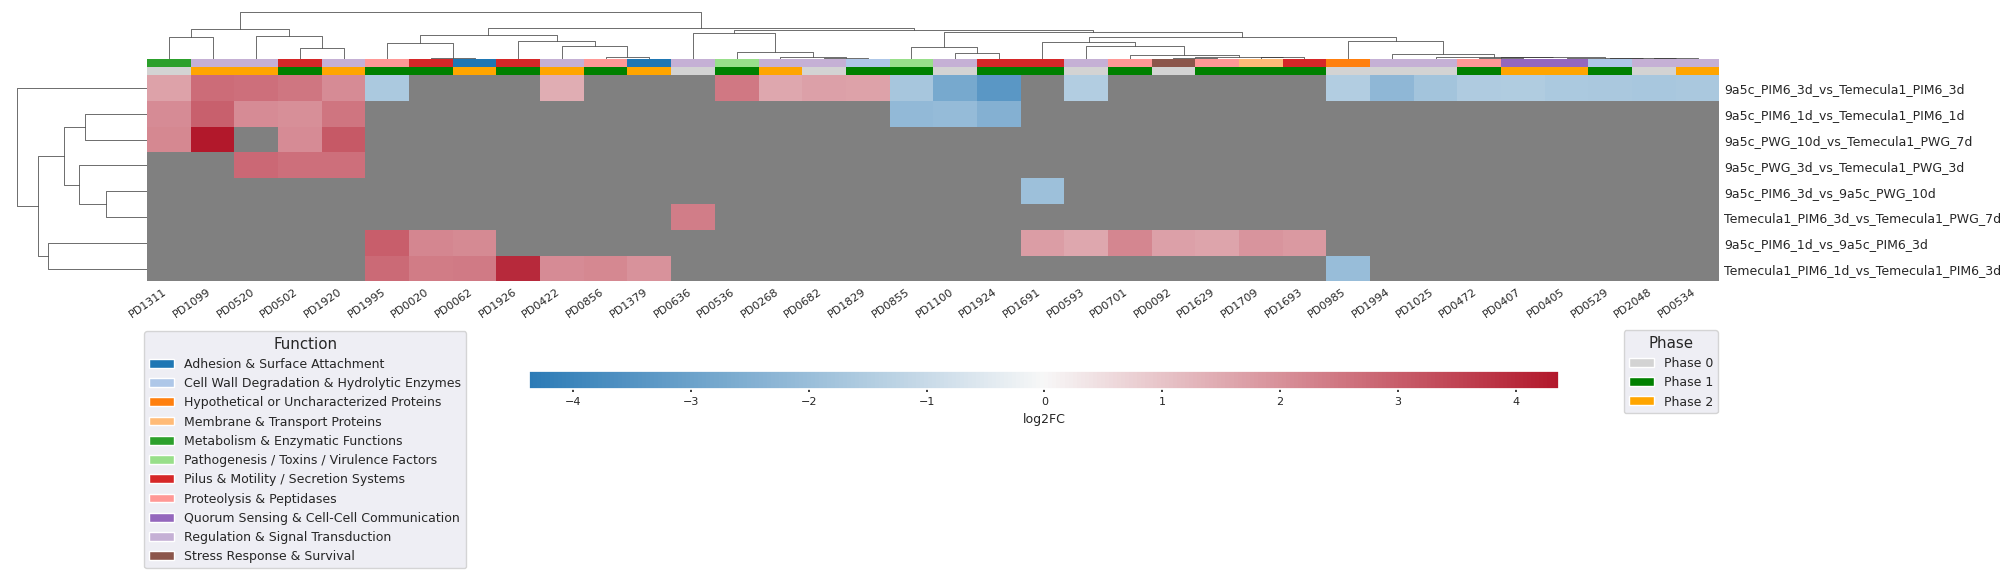

In [18]:
# Cell 11 – Virulence-gene clustermap across all DESeq2 comparisons
# ---------------------------------------------------------------
# Preconditions (already defined in earlier cells):
#   - OUTDIR: Path to the root DESeq2 results folder (with *_vs_* subfolders)
#   - dict_df & choose_old_tag: gene mapping dictionary + helper
#   - VIR_TABLE: Path to virulence_table.csv
#   - VIR_HEATMAP: Path to output heatmap .tiff

OUTDIR = Path(OUTDIR)           # ensure Path type
VIR_TABLE = Path(VIR_TABLE)
VIR_HEATMAP = Path(VIR_HEATMAP)

MIN_DYNAMIC_COLUMNS = 1         # minimum number of vir genes with signal to allow plotting
DEG_GLOB = "DEGs_annotated_p*_LFC*.csv"

# -------------------------- small helpers -------------------------- #

def read_table_fallback(p: Path) -> pd.DataFrame:
    """Read CSV/TSV with robust encoding / separator handling."""
    try:
        return pd.read_csv(p, sep=None, engine="python", encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(p, sep=None, engine="python", encoding="latin1")
    except Exception:
        return pd.read_csv(p, encoding="latin1")

def load_virulence_table(path: Path) -> pd.DataFrame:
    """
    Load virulence_table.csv and standardise columns:
      tem_gene_id, Function, Description, Phase
    """
    if not path.exists():
        raise FileNotFoundError(f"Virulence table not found at {path}")
    df = read_table_fallback(path)
    df.columns = [c.strip() for c in df.columns]

    # 1) gene ID column (Temecula1 PD####)
    gene_col = None
    for c in df.columns:
        if "gene id" in c.lower() or "temecula" in c.lower() or "pd" in c.lower():
            gene_col = c
            break
    if gene_col is None:
        for c in df.columns:
            sample = df[c].dropna().astype(str).head(50).tolist()
            if sample and sum(1 for s in sample if re.match(r"PD_?\d+", s.strip(), re.I)) >= max(1, len(sample) // 3):
                gene_col = c
                break
    if gene_col is None:
        raise RuntimeError("Could not find Temecula1 gene ID column in virulence table.")
    df = df.rename(columns={gene_col: "tem_gene_id"})

    # 2) Function / Description / Phase columns
    for c in df.columns:
        cl = c.lower()
        if "function" in cl and "Function" not in df.columns:
            df = df.rename(columns={c: "Function"})
        if ("description" in cl or "desc" in cl) and "Description" not in df.columns:
            df = df.rename(columns={c: "Description"})
        if "phase" in cl and "Phase" not in df.columns:
            df = df.rename(columns={c: "Phase"})

    df = df.fillna({"Function": "Unknown", "Description": "", "Phase": 0})
    df["tem_gene_id"] = (
        df["tem_gene_id"].astype(str).str.replace("_", "", regex=False).str.strip()
    )
    df["Phase"] = pd.to_numeric(df["Phase"], errors="coerce").fillna(0).astype(int)

    return (
        df[["tem_gene_id", "Function", "Description", "Phase"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

# -------------------------- load virulence list -------------------------- #

vir_df = load_virulence_table(VIR_TABLE)
vir_genes = vir_df["tem_gene_id"].tolist()
print(f"Loaded {len(vir_genes)} virulence genes (example): {vir_genes[:6]}")

# -------------------------- build ID → Temecula PD mapping -------------------------- #

id_to_tem_old: dict[str, str] = {}

d = dict_df.copy()
d.columns = [c.strip() for c in d.columns]

tem_old_col = next(
    (c for c in d.columns
     if "temecula1_old" in c.lower()
     or "temecula1_old_locus" in c.lower()
     or "temecula1_old_locus_tags" in c.lower()),
    None,
)
tem_locus_col = next((c for c in d.columns if "temecula1_locus_tag" in c.lower()), None)
tem_img_col = next(
    (c for c in d.columns
     if "temecula1_img" in c.lower() or ("temecula" in c.lower() and "img" in c.lower())),
    None,
)
nine_old_col = next((c for c in d.columns if "9a5c_old" in c.lower()), None)
nine_img_col = next((c for c in d.columns if "9a5c_img" in c.lower()), None)

for _, row in d.iterrows():
    tem_tag = None
    if tem_old_col and pd.notna(row.get(tem_old_col)):
        tem_tag = choose_old_tag(row.get(tem_old_col))
    if not tem_tag and tem_locus_col and pd.notna(row.get(tem_locus_col)):
        tem_tag = str(row.get(tem_locus_col)).strip()
    if not tem_tag and tem_img_col and pd.notna(row.get(tem_img_col)):
        tem_tag = str(row.get(tem_img_col)).strip()
    if not tem_tag:
        continue

    tem_tag = tem_tag.replace("_", "")
    for v in {tem_tag, tem_tag.upper(), tem_tag.lower()}:
        id_to_tem_old[v] = tem_tag

    if nine_old_col and pd.notna(row.get(nine_old_col)):
        nine_tag = choose_old_tag(row.get(nine_old_col))
        if nine_tag:
            id_to_tem_old[nine_tag] = tem_tag
            id_to_tem_old[nine_tag.replace("_", "")] = tem_tag
    if nine_img_col and pd.notna(row.get(nine_img_col)):
        v = str(row.get(nine_img_col)).strip()
        if v:
            id_to_tem_old[v] = tem_tag

# vir genes always map to themselves
for vg in vir_genes:
    id_to_tem_old[vg] = vg
    id_to_tem_old[vg.replace("_", "")] = vg

print("Built id→PD mapping with", len(id_to_tem_old), "keys",
      "sample:", list(id_to_tem_old.items())[:6])

def map_to_tem_old(gid: str | None) -> str | None:
    """Map any gene id (IMG / old locus tag / XF) to a canonical Temecula PD#### tag."""
    if gid is None:
        return None
    s = str(gid).strip()
    if s in id_to_tem_old:
        return id_to_tem_old[s]
    s_no = s.replace("_", "")
    if s_no in id_to_tem_old:
        return id_to_tem_old[s_no]
    if s.upper() in id_to_tem_old:
        return id_to_tem_old[s.upper()]
    if s.lower() in id_to_tem_old:
        return id_to_tem_old[s.lower()]
    m = re.match(r"([PXD]F?0*\d+)", s, re.I)
    if m:
        candidate = s.replace("_", "").upper()
        if candidate in id_to_tem_old:
            return id_to_tem_old[candidate]
    return None

# -------------------------- scan DESeq2 comparison folders -------------------------- #

comp_folders: list[tuple[str, Path, Path]] = []
for p in sorted(OUTDIR.iterdir()):
    if p.is_dir() and "_vs_" in p.name:
        cand = list(p.glob(DEG_GLOB))
        if cand:
            comp_folders.append((p.name, p, cand[0]))
        else:
            fallback = list(p.glob("DESeq2_results_full*.csv"))
            if fallback:
                comp_folders.append((p.name, p, fallback[0]))

print(f"Found {len(comp_folders)} comparison folders with candidate DEG files.")
if not comp_folders:
    raise RuntimeError(f"No comparison folders with DEG files found under {OUTDIR}")

# -------------------------- build comparison × vir-gene matrix -------------------------- #

comp_names = [name for name, _, _ in comp_folders]
matrix = pd.DataFrame(index=comp_names, columns=vir_genes, dtype=float)
matrix[:] = np.nan

for comp_name, comp_path, deg_file in tqdm(comp_folders, desc="comparisons", unit="comp"):
    try:
        res = read_table_fallback(deg_file)
    except Exception as e:
        tqdm.write(f"[WARN] cannot read {deg_file}: {e}")
        continue

    res.columns = [c.strip() for c in res.columns]
    if "gene_id" not in res.columns:
        res = res.rename(columns={res.columns[0]: "gene_id"})

    # find log2FC column
    if "log2FoldChange" in res.columns:
        fc_col = "log2FoldChange"
    else:
        fc_col = next(
            (c for c in res.columns if "log2" in c.lower() and "fold" in c.lower()),
            None,
        )
    if fc_col is None:
        tqdm.write(f"[WARN] {deg_file} missing log2FoldChange-like column; skipping {comp_name}")
        continue

    old_col = next((c for c in res.columns if "old" in c.lower() and "locus" in c.lower()), None)

    res_map: dict[str, float] = {}
    for _, row in res.dropna(subset=["gene_id"]).iterrows():
        gid_raw = str(row["gene_id"]).strip()
        try:
            val = float(row[fc_col])
        except Exception:
            continue

        mapped_tag = None
        if old_col and pd.notna(row.get(old_col)):
            mapped_tag = choose_old_tag(row.get(old_col))
            if mapped_tag:
                mapped_tag = map_to_tem_old(mapped_tag) or mapped_tag.replace("_", "")
        if not mapped_tag:
            mapped_tag = map_to_tem_old(gid_raw)

        if mapped_tag:
            mapped_tag = mapped_tag.replace("_", "")
            prev = res_map.get(mapped_tag)
            if prev is None or abs(val) > abs(prev):
                res_map[mapped_tag] = val
        else:
            # keep raw forms only if they exactly match PD in vir_gene list
            for cand in {gid_raw, gid_raw.replace("_", ""), gid_raw.upper(), gid_raw.lower()}:
                if cand in vir_genes:
                    prev = res_map.get(cand)
                    if prev is None or abs(val) > abs(prev):
                        res_map[cand] = val

    mapped_count = 0
    for vg in vir_genes:
        if vg in res_map:
            matrix.at[comp_name, vg] = res_map[vg]
            mapped_count += 1

    tqdm.write(f"[INFO] {comp_name}: mapped {mapped_count} vir genes")

# drop empty rows and columns
rows_before = matrix.shape[0]
matrix = matrix.dropna(axis=0, how="all")
rows_after = matrix.shape[0]
print(f"Dropped {rows_before - rows_after} comparisons with no mapped vir genes. Remaining comparisons: {rows_after}")

cols_before = matrix.shape[1]
cols_with_signal = matrix.columns[matrix.notna().any()].tolist()
matrix = matrix.loc[:, cols_with_signal]
cols_after = matrix.shape[1]
print(f"Dropped {cols_before - cols_after} vir genes with no signal. Remaining genes: {cols_after}")

if matrix.empty or matrix.shape[1] < MIN_DYNAMIC_COLUMNS:
    raise RuntimeError("Not enough data to plot after filtering (no remaining comparisons or vir genes).")

# -------------------------- side-color annotations -------------------------- #

col_meta = vir_df.set_index("tem_gene_id").reindex(matrix.columns)
col_meta["Function"] = col_meta["Function"].fillna("Unknown")
unique_groups = sorted(col_meta["Function"].unique().tolist())
palette = sns.color_palette("tab20", n_colors=max(2, len(unique_groups)))
group_colors = dict(zip(unique_groups, palette))
function_colors = [
    group_colors.get(col_meta.loc[g, "Function"], (0.5, 0.5, 0.5))
    for g in matrix.columns
]

phase_palette = {0: "lightgrey", 1: "green", 2: "orange"}
col_meta["Phase"] = col_meta["Phase"].fillna(0).astype(int)
phase_colors = [
    phase_palette.get(col_meta.loc[g, "Phase"], "black")
    for g in matrix.columns
]

col_colors_stacked = [function_colors, phase_colors]

# -------------------------- clustermap plotting -------------------------- #

mask_missing = matrix.isna()
data_for_cluster = matrix.fillna(0.0)

all_vals = matrix.stack(dropna=True)
vmax = max(abs(all_vals.min()), abs(all_vals.max())) if not all_vals.empty else 1.0
vmin = -vmax

cmap = LinearSegmentedColormap.from_list("custom_div", ["#2c7bb6", "#f7f7f7", "#b2182b"])
cmap.set_bad(color="#808080")

ncols = matrix.shape[1]
fig_w = max(12, min(40, 0.35 * ncols + 8))
fig_h = max(6, 0.4 * data_for_cluster.shape[0])
sns.set(font_scale=0.9)

g = sns.clustermap(
    data_for_cluster,
    cmap=cmap,
    mask=mask_missing,
    col_colors=col_colors_stacked,
    figsize=(fig_w, fig_h),
    linewidths=0.0,
    center=0,
    vmin=vmin,
    vmax=vmax,
    metric="euclidean",
    method="average",
    col_cluster=True,
    row_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.08, 0.18),   # shrink row dendrogram
    cbar_pos=None                    # disable built-in colorbar
)

# x-labels
xticks = g.ax_heatmap.get_xticklabels()
g.ax_heatmap.set_xticklabels(
    [t.get_text() for t in xticks],
    rotation=35,
    ha="right",
    fontsize=8,
)

# y-labels
g.ax_heatmap.set_yticklabels(
    [lbl.get_text().lstrip("- ").strip() for lbl in g.ax_heatmap.get_yticklabels()],
    rotation=0,
    fontsize=9,
)

g.ax_heatmap.tick_params(axis="y", which="both", length=0)
g.ax_heatmap.tick_params(axis="x", which="both", length=0)

# move heatmap up to create space for legends / colorbar
g.fig.subplots_adjust(bottom=0.52)

# horizontal colorbar under the heatmap
cbar_ax = g.fig.add_axes([0.26, 0.34, 0.50, 0.03])
cbar = g.fig.colorbar(
    g.ax_heatmap.collections[0],
    cax=cbar_ax,
    orientation="horizontal",
)
cbar.ax.tick_params(labelsize=8, length=2)
cbar.set_label("log2FC", fontsize=9)

# -------------------------- legends (Function / Phase) -------------------------- #

func_handles = [Patch(facecolor=group_colors[k], label=k) for k in sorted(group_colors.keys())]
phase_handles = [Patch(facecolor=phase_palette[k], label=f"Phase {k}") for k in sorted(phase_palette.keys())]

func_legend = g.fig.legend(
    handles=func_handles,
    labels=[h.get_label() for h in func_handles],
    title="Function",
    loc="lower left",
    bbox_to_anchor=(0.07, 0.032),
    bbox_transform=g.fig.transFigure,
    fontsize="small",
    frameon=True,
)

phase_legend = g.fig.legend(
    handles=phase_handles,
    labels=[h.get_label() for h in phase_handles],
    title="Phase",
    loc="lower right",
    bbox_to_anchor=(0.84, 0.29),
    bbox_transform=g.fig.transFigure,
    fontsize="small",
    frameon=True,
)

# -------------------------- save / show -------------------------- #

g.fig.savefig(
    VIR_HEATMAP,
    dpi=600,
    bbox_inches="tight",
    bbox_extra_artists=(func_legend, phase_legend),
)
plt.show()


In [17]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results


In [21]:
# Cell: GO bubble-plot builder (robust, adaptive)
# Expects:
#   - OUTDIR (Path) defined earlier and pointing to the DESeq2 results root (same OUTDIR as in other notebook)
#   - The GO enrichment CSV files are in subfolders under OUTDIR and contain columns:
#       'go_term', 'p_value' or 'p_value'/'p_adj', 'p_adj' (or 'p.value' style), 
#       'deg_count' (count of DEG with term), 'bg_count', 'deg_percentage', 'fold_enrichment'
#   - If your GO files use different names, adjust GO_GLOB below.
# Options you can tweak: TOP_N_TERMS, P_ADJ_CUTOFF, SIZE_SCALE.
#
# This cell:
#   - finds GO CSVs, merges them into a table, selects top terms per comparison,
#   - plots one bubble plot per comparison with adaptive layout,
#   - places colorbar under the entire figure and size legend beneath each subplot.

import math, textwrap, glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.patches import Patch

# ------------- USER ADJUSTABLE PARAMETERS -------------
GO_GLOB = "**/GO_enrichment_*.csv"  # glob from OUTDIR; change if your files have other pattern
TOP_N_TERMS = 12                     # how many GO terms to show per comparison (best by p_adj)
P_ADJ_CUTOFF = 0.05                  # threshold to highlight significant GO terms
SIZE_SCALE = 600.0                   # controls bubble area scaling (tune visually)
MAX_COLS = 3                         # max subplots per row
MIN_BUBBLE = 30                      # minimal bubble size (avoid invisible points)
VERBOSE = True
# ----------------------------------------------------

OUTDIR = Path(OUTDIR)  # must exist; reuse from earlier notebook

def read_table_fallback(p: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(p, sep=None, engine="python", encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(p, sep=None, engine="python", encoding="latin1")
    except Exception:
        return pd.read_csv(p)

# find GO files
go_files = sorted([Path(p) for p in glob.glob(str(OUTDIR / GO_GLOB), recursive=True)])
if VERBOSE:
    print(f"Found {len(go_files)} GO enrichment files (using pattern {GO_GLOB}).")

if len(go_files) == 0:
    raise FileNotFoundError(f"No GO enrichment files found under {OUTDIR} with pattern {GO_GLOB}.")

# load and standardize each file into a dataframe with expected columns
dfs = []
for p in go_files:
    try:
        df = read_table_fallback(p)
    except Exception as e:
        print(f"[WARN] cannot read {p}: {e}")
        continue
    df.columns = [c.strip() for c in df.columns]
    # heuristics: find key columns (be tolerant)
    col_map = {}
    col_map['go_term'] = next((c for c in df.columns if c.lower().startswith('go_') or 'go:' in str(df[c].astype(str).head(5).values)), None)
    col_map['go_term'] = col_map['go_term'] or next((c for c in df.columns if 'go_term' in c.lower() or 'go id' in c.lower() or 'term' in c.lower()), None)
    col_map['p_adj'] = next((c for c in df.columns if c.lower() in ('p_adj','padj','p.adj','p_adj.','adj_p','p.adjust','qvalue','fdr')), None)
    col_map['p_value'] = next((c for c in df.columns if c.lower() in ('p_value','p.value','pval','pvalue','p')), None)
    col_map['deg_count'] = next((c for c in df.columns if 'deg_count' in c.lower() or 'deg' in c.lower() and 'count' in c.lower()), None)
    col_map['deg_count'] = col_map['deg_count'] or next((c for c in df.columns if 'count' in c.lower() and 'bg' not in c.lower()), None)
    col_map['fold_enrichment'] = next((c for c in df.columns if 'fold' in c.lower() and 'enrich' in c.lower()), None)
    col_map['deg_percentage'] = next((c for c in df.columns if 'deg_percentage' in c.lower() or 'deg%' in c.lower()), None)

    # fallback: try to guess go_term from first column
    if col_map['go_term'] is None:
        col_map['go_term'] = df.columns[0]

    # build standardized df
    std = pd.DataFrame()
    std['go_term'] = df[col_map['go_term']].astype(str)
    # pick p_adj if available else p_value else NaN
    if col_map['p_adj'] is not None:
        std['p_adj'] = pd.to_numeric(df[col_map['p_adj']], errors='coerce')
    elif col_map['p_value'] is not None:
        std['p_adj'] = pd.to_numeric(df[col_map['p_value']], errors='coerce')
    else:
        std['p_adj'] = np.nan

    std['deg_count'] = pd.to_numeric(df[col_map['deg_count']], errors='coerce') if col_map['deg_count'] else np.nan
    std['fold_enrichment'] = pd.to_numeric(df[col_map['fold_enrichment']], errors='coerce') if col_map['fold_enrichment'] else np.nan
    std['deg_percentage'] = pd.to_numeric(df[col_map['deg_percentage']], errors='coerce') if col_map['deg_percentage'] else np.nan

    # annotate which comparison this file came from (folder name / file stem)
    comp = p.parent.name
    # if file name contains comparison, prefer that
    if "_vs_" in p.stem:
        comp = p.stem
    std['comparison'] = comp
    std['source_file'] = str(p)
    dfs.append(std)

# combine
go_all = pd.concat(dfs, axis=0, ignore_index=True)
# drop rows without go_term
go_all = go_all[go_all['go_term'].notna()].copy()

# if deg_percentage missing, compute if deg_count & background count present (not guaranteed)
# If not available, deg_count will control bubble size.
go_all['deg_count'] = go_all['deg_count'].fillna(0).astype(float)
go_all['fold_enrichment'] = go_all['fold_enrichment'].fillna(0).astype(float)
go_all['deg_percentage'] = go_all['deg_percentage'].fillna(0).astype(float)
go_all['p_adj'] = go_all['p_adj'].fillna(1.0).astype(float)

# Choose top terms per comparison by significance then by fold enrichment
selected_rows = []
for comp, grp in go_all.groupby('comparison'):
    # sort by p_adj then fold_enrichment desc then deg_count desc
    grp_sorted = grp.sort_values(['p_adj','fold_enrichment','deg_count'], ascending=[True, False, False])
    pick = grp_sorted.head(TOP_N_TERMS).copy()
    pick['rank'] = np.arange(1, len(pick)+1)
    selected_rows.append(pick)

if not selected_rows:
    raise RuntimeError("No GO terms selected for plotting (empty GO results).")

go_selected = pd.concat(selected_rows, axis=0, ignore_index=True)

# ------------------ plotting ------------------

# unique comparisons and layout
comps = sorted(go_selected['comparison'].unique().tolist())
n_comps = len(comps)
ncols = min(MAX_COLS, n_comps)
nrows = math.ceil(n_comps / ncols)

# dynamic figure sizing: base width per subplot, base height per subplot
w_per = 5.0
h_per = 3.5
fig_w = min(20, max(6, ncols * w_per))
fig_h = max(3.5, nrows * h_per)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), squeeze=False)
plt.subplots_adjust(hspace=0.45, wspace=0.3, bottom=0.18, top=0.95)

# global color mapping: map fold_enrichment → color scale
# NOTE: not forcing any color palette choice; using matplotlib default colormap 'viridis'
norm_vals = go_selected['fold_enrichment'].replace([np.inf, -np.inf], np.nan).dropna()
if not norm_vals.empty:
    vmin = norm_vals.min()
    vmax = norm_vals.max()
else:
    vmin, vmax = 0.0, 1.0

cmap = cm.get_cmap('viridis')

# size scaling: use deg_count relative to max in the selected set
max_deg = max(go_selected['deg_count'].max(), 1.0)

# helper to wrap long GO labels
def wrap_label(s, width=40):
    return textwrap.fill(str(s), width=width)

# store proxies for size legend (common across subplots)
size_legend_values = sorted({int(x) for x in np.linspace(1, max_deg if max_deg>0 else 1, 3)})

for i, comp in enumerate(comps):
    r = i // ncols
    c = i % ncols
    ax = axes[r][c]

    df = go_selected[go_selected['comparison'] == comp].copy()
    if df.empty:
        ax.axis('off')
        continue

    # y-axis categories: use wrapped GO term + optionally short desc
    # If go_term contains ' - ' with description, split for label; else use go_term itself
    df['label'] = df['go_term'].apply(lambda s: wrap_label(s, width=50))

    # order terms by rank so top is on top of the plot
    df = df.sort_values('rank', ascending=True)
    y_pos = np.arange(len(df), 0, -1)  # descending so top-ranked is at top

    # bubble sizes: proportional to deg_count
    sizes = (df['deg_count'] / max_deg.clip(min=1.0)) * SIZE_SCALE
    sizes = sizes.clip(lower=MIN_BUBBLE)

    # colors: fold_enrichment scaled to cmap
    # handle constant fold_enrichment by mapping to single color
    if np.isclose(vmax, vmin):
        colors = [cmap(0.5) for _ in df['fold_enrichment']]
        smappable = None
    else:
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        colors = cmap(norm(df['fold_enrichment'].fillna(vmin)))
        smappable = cm.ScalarMappable(norm=norm, cmap=cmap)
        smappable.set_array([])

    # plot
    ax.scatter(df['deg_percentage'], y_pos, s=sizes, c=colors, edgecolors='k', linewidths=0.3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['label'])
    ax.set_title(comp, fontsize=9)
    ax.set_xlabel('DEG (%)', fontsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # mark significant terms with a star on the right of the bubble
    for xi, yi, padj in zip(df['deg_percentage'], y_pos, df['p_adj']):
        if padj <= P_ADJ_CUTOFF:
            ax.text(xi + max(0.5, df['deg_percentage'].max()*0.02), yi, "*", va='center', fontsize=10, color='red')

    # add small gridlines for readability
    ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.6)

# remove empty subplots
for j in range(len(comps), nrows * ncols):
    r = j // ncols
    c = j % ncols
    axes[r][c].axis('off')

# global colorbar under the full figure
if smappable is not None:
    cax = fig.add_axes([0.18, 0.06, 0.64, 0.04])  # [left, bottom, width, height] in figure coords
    cb = fig.colorbar(smappable, cax=cax, orientation='horizontal')
    cb.set_label('Fold enrichment', fontsize=9)
    cb.ax.tick_params(labelsize=8)
else:
    # no colorbar needed if all fold_enrichment are identical
    pass

# size legend proxies (one legend under the plot)
proxy_handles = []
proxy_labels = []
for val in size_legend_values:
    s = (val / max_deg) * SIZE_SCALE
    s = max(s, MIN_BUBBLE)
    proxy_handles.append(plt.scatter([], [], s=s, edgecolors='k', color='lightgray'))
    proxy_labels.append(str(val))

# place size legend centered below panels
if proxy_handles:
    legend = fig.legend(proxy_handles, proxy_labels, title='DEG count',
                        loc='lower center', bbox_to_anchor=(0.5, 0.01),
                        ncol=len(proxy_handles), fontsize=8, frameon=True)
    legend.get_title().set_fontsize(9)

plt.suptitle("GO enrichment bubble plots (top terms per comparison)", fontsize=11)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])  # leave space for colorbar & size legend
plt.show()